# Who Should We Email? From A/B Test to Targeting

**A beginner-friendly causal inference project on real data: the Hillstrom email experiment (64,000 customers)**

---

In 2008 an online retailer ran an experiment. It split its customers into three random groups:

- one group got an email about **men's** products,
- one group got an email about **women's** products,
- one group got **no email**.

Two weeks later, the retailer recorded who visited the website, who bought something, and how much they spent.

We will answer three questions:

1. **Did the emails work?** On average, did emailed customers visit and spend more?
2. **Who did they work for?** Did some kinds of customers respond more than others?
3. **Who should we email next time?** Can we pick the customers worth emailing and skip the rest?

**Data:** Kevin Hillstrom, *MineThatData E-Mail Analytics and Data Mining Challenge* (2008).

## The one idea behind everything: four kinds of customers

Imagine every customer secretly belongs to one of four types, depending on how they react to our email:

| | Buys **without** the email | Doesn't buy without the email |
|---|---|---|
| **Buys with the email** | 😐 **Sure thing** — would have bought anyway | 🎯 **Persuadable** — the email *made* them buy |
| **Doesn't buy with the email** | 💤 **Sleeping dog** — the email *annoys* them away | 🪨 **Lost cause** — nothing works |

- Emailing a **persuadable** earns money.
- Emailing a **sure thing** or a **lost cause** wastes money.
- Emailing a **sleeping dog** loses money.

**The problem:** we can never see a customer's type. Each customer either got the email or didn't — never both — so we never see what they *would have done* the other way.

**The solution: randomization.** Because a coin flip decided who got the email, each group contains the same mix of the four types. So if the emailed group behaves differently from the no-email group, the email must be the reason.

We will come back to these four types throughout the notebook.

## 1. Setup

We import the libraries we need:

- `pandas` and `numpy` for tables and math
- `matplotlib` for charts
- `scikit-learn` for machine learning models
- `scikit-uplift` for one evaluation score
- `econml` for the causal forest model

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklift.metrics import qini_auc_score
from econml.dml import CausalForestDML

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

BLUE = "#2a6fdb"
ORANGE = "#e4572e"
GREY = "#9aa5b1"

## 2. Load the data

The file is the original CSV from the MineThatData blog, saved as `data/hillstrom.csv`.

(If you don't have the file, `scikit-uplift` can download the same data: `from sklift.datasets import fetch_hillstrom`.)

In [2]:
df = pd.read_csv("data/hillstrom.csv")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


**What each column means**

*Measured **before** the email (the customer's history):*

| Column | Meaning |
|---|---|
| `recency` | Months since the customer's last purchase (1 to 12) |
| `history` | Dollars spent in the past year |
| `history_segment` | The same thing as `history`, grouped into ranges |
| `mens` | 1 if they bought men's products in the past year |
| `womens` | 1 if they bought women's products in the past year |
| `zip_code` | Urban, Suburban (spelled *Surburban* in the file) or Rural |
| `newbie` | 1 if they became a customer in the past year |
| `channel` | How they bought before: Phone, Web or Multichannel |

*The experiment:*

| Column | Meaning |
|---|---|
| `segment` | Which group they were randomly put in: Mens E-Mail, Womens E-Mail or No E-Mail |

*Measured **after** the email (the outcomes):*

| Column | Meaning |
|---|---|
| `visit` | 1 if they visited the website in the next two weeks |
| `conversion` | 1 if they bought something |
| `spend` | Dollars spent |

In experiment language, each of the three groups is called an **arm**. The No E-Mail group is the **control** arm. Let's see how many customers are in each arm.

In [3]:
df["segment"].value_counts()

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

## 3. Check that the randomization worked

Before we measure anything, we check that the three groups really are comparable. If the groups were already different before the email, we couldn't tell whether a later difference came from the email or from the groups themselves.

### Check 1: Are the groups the right size?

The retailer meant to split customers into three equal groups. If one group were much bigger or smaller than expected, something would have gone wrong with the assignment.

A **chi-square test** asks: "If the split really were fair, how surprising would group sizes like these be?" A large p-value (above 0.05) means "not surprising — the split looks fair."

In [4]:
group_sizes = df["segment"].value_counts()
test_result = chisquare(group_sizes)
print("Share of customers in each group:")
print(group_sizes / len(df))
print()
print("Chi-square p-value:", round(test_result.pvalue, 3))

Share of customers in each group:
segment
Womens E-Mail    0.334172
Mens E-Mail      0.332922
No E-Mail        0.332906
Name: count, dtype: float64

Chi-square p-value: 0.904


Each group has almost exactly one third of the customers, and the p-value is large. The split looks fair.

### Check 2: Do the groups look alike?

Next we compare each email group with the No E-Mail group on every "before" column. We use the **standardized mean difference (SMD)**:

1. Take the average of a column in the email group, and the average in the no-email group.
2. Subtract them to get the gap.
3. Divide the gap by the typical spread of that column (its standard deviation).

**Example:** last year's spend (`history`) averages 242.84 in the Mens E-Mail group and 240.88 in the No E-Mail group, a gap of 1.95. Customers typically differ from each other by about \$257, so the SMD is 1.95 ÷ 257 ≈ **0.008**. The gap is tiny compared with normal differences between customers.

Dividing by the spread puts every column on the same scale, whether it's in dollars, months or yes/no. **Rule of thumb: an SMD below 0.1 means the groups are alike on that column.**

In [5]:
def smd(group_a, group_b):
    gap = group_a.mean() - group_b.mean()
    spread = np.sqrt((group_a.var() + group_b.var()) / 2)
    return gap / spread

Some columns are text (`zip_code`, `channel`). `pd.get_dummies` turns each text value into its own 0/1 column, for example `zip_code_Rural` = 1 if the customer lives in a rural area.

In [6]:
before_columns = ["recency", "history", "mens", "womens", "newbie", "zip_code", "channel"]
before = pd.get_dummies(df[before_columns], dtype=float)
before.columns.tolist()

['recency',
 'history',
 'mens',
 'womens',
 'newbie',
 'zip_code_Rural',
 'zip_code_Surburban',
 'zip_code_Urban',
 'channel_Multichannel',
 'channel_Phone',
 'channel_Web']

In [7]:
before.head()

,recency,history,mens,womens,newbie,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web
0,10,142.44,1,0,0,0.0,1.0,0.0,0.0,1.0,0.0
1,6,329.08,1,1,1,1.0,0.0,0.0,0.0,0.0,1.0
2,7,180.65,0,1,1,0.0,1.0,0.0,0.0,0.0,1.0
3,9,675.83,1,0,1,1.0,0.0,0.0,0.0,0.0,1.0
4,2,45.34,1,0,0,0.0,0.0,1.0,0.0,0.0,1.0


In [8]:
is_control = df["segment"] == "No E-Mail"
is_mens = df["segment"] == "Mens E-Mail"
is_womens = df["segment"] == "Womens E-Mail"

rows = []
for column in before.columns:
    control_values = before.loc[is_control, column]
    mens_values = before.loc[is_mens, column]
    womens_values = before.loc[is_womens, column]

    row = {"column": column,
           "Mens vs No E-Mail": smd(mens_values, control_values),
           "Womens vs No E-Mail": smd(womens_values, control_values)}
    rows.append(row)

balance = pd.DataFrame(rows)
balance.round(3)

,column,Mens vs No E-Mail,Womens vs No E-Mail
0,recency,0.007,0.005
1,history,0.008,0.007
2,mens,-0.005,-0.009
3,womens,0.008,0.005
4,newbie,-0.001,0.003
5,zip_code_Rural,0.014,0.004
6,zip_code_Surburban,-0.012,-0.001
7,zip_code_Urban,0.002,-0.002
8,channel_Multichannel,-0.004,-0.005
9,channel_Phone,-0.008,0.009


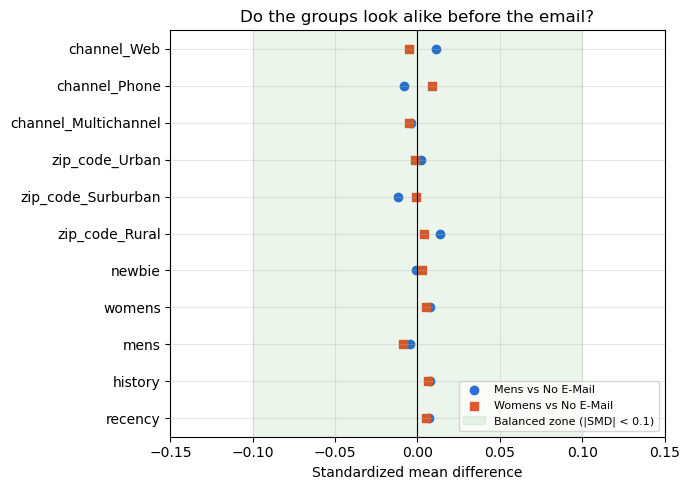

In [9]:
positions = np.arange(len(balance))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(balance["Mens vs No E-Mail"], positions, color=BLUE, label="Mens vs No E-Mail")
ax.scatter(balance["Womens vs No E-Mail"], positions, color=ORANGE, marker="s", label="Womens vs No E-Mail")
ax.axvspan(-0.1, 0.1, color="green", alpha=0.08, label="Balanced zone (|SMD| < 0.1)")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(positions)
ax.set_yticklabels(balance["column"])
ax.set_xlim(-0.15, 0.15)
ax.set_xlabel("Standardized mean difference")
ax.set_title("Do the groups look alike before the email?")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Every value is below 0.02, far inside the balanced zone.

**Important: this is not a test of whether the email worked.** These columns were all measured *before* the email was sent, so the email can't have changed them. The check only tells us the three groups started out alike. Because the groups started alike, any difference we find *after* the email can be credited to the email.

## 4. Did the emails work?

Because the groups are comparable, the effect of an email is simply:

> **average outcome in the email group − average outcome in the no-email group**

In the four-types picture: the email group's buy rate includes sure things *and* persuadables; the no-email group's includes sure things *and* sleeping dogs. Subtracting cancels out the sure things, leaving the people the email actually moved.

First, the raw averages:

In [10]:
df.groupby("segment")[["visit", "conversion", "spend"]].mean().round(4)

,visit,conversion,spend
segment,,,
Mens E-Mail,0.1828,0.0125,1.4226
No E-Mail,0.1062,0.0057,0.6528
Womens E-Mail,0.1514,0.0088,1.0772


The emailed groups visited more, bought more and spent more. But is the difference real, or could it be luck?

A **95% confidence interval** answers that. It's a range that, 95% of the time, contains the true effect. If the whole range is above zero, we can be confident the email helped.

To build it we need the **standard error**: how much the difference would wobble if we reran the experiment with different random customers. For a difference between two groups:

$$\text{standard error} = \sqrt{\frac{\text{variance}_{\text{email}}}{n_{\text{email}}} + \frac{\text{variance}_{\text{no email}}}{n_{\text{no email}}}}$$

The 95% interval is then *difference ± 1.96 × standard error*.

In [11]:
def compare_groups(email_values, control_values):
    difference = email_values.mean() - control_values.mean()
    standard_error = np.sqrt(email_values.var() / len(email_values)
                             + control_values.var() / len(control_values))
    ci_low = difference - 1.96 * standard_error
    ci_high = difference + 1.96 * standard_error
    return difference, standard_error, ci_low, ci_high

In [12]:
rows = []
for arm in ["Mens E-Mail", "Womens E-Mail"]:
    for outcome in ["visit", "conversion", "spend"]:
        email_values = df.loc[df["segment"] == arm, outcome]
        control_values = df.loc[is_control, outcome]
        difference, standard_error, ci_low, ci_high = compare_groups(email_values, control_values)

        row = {"email": arm, "outcome": outcome, "effect": difference,
               "ci_low": ci_low, "ci_high": ci_high,
               "lift_%": 100 * difference / control_values.mean()}
        rows.append(row)

effects = pd.DataFrame(rows)
effects.round(4)

,email,outcome,effect,ci_low,ci_high,lift_%
0,Mens E-Mail,visit,0.0766,0.0700,0.0832,72.1405
1,Mens E-Mail,conversion,0.0068,0.0050,0.0086,118.8422
2,Mens E-Mail,spend,0.7698,0.4851,1.0545,117.9289
3,Womens E-Mail,visit,0.0452,0.0389,0.0516,42.6055
4,Womens E-Mail,conversion,0.0031,0.0015,0.0047,54.3313
5,Womens E-Mail,spend,0.4244,0.1690,0.6799,65.0152


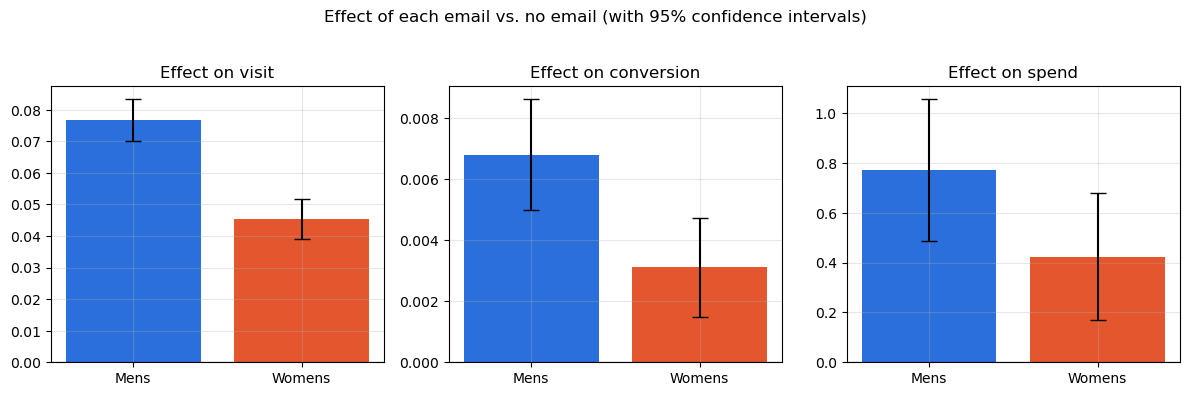

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
outcomes = ["visit", "conversion", "spend"]

for i in range(3):
    outcome = outcomes[i]
    ax = axes[i]
    part = effects[effects["outcome"] == outcome]
    error_below = part["effect"] - part["ci_low"]
    error_above = part["ci_high"] - part["effect"]
    labels = ["Mens", "Womens"]
    ax.bar(labels, part["effect"], color=[BLUE, ORANGE],
           yerr=[error_below, error_above], capsize=6)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Effect on " + outcome)

plt.suptitle("Effect of each email vs. no email (with 95% confidence intervals)", y=1.03)
plt.tight_layout()
plt.show()

**Both emails worked.** Every confidence interval is above zero.

- The **men's email** raised the visit rate by about 7.7 percentage points (from 10.6% to 18.3%, a 72% increase) and spend by about \$0.77 per customer.
- The **women's email** raised the visit rate by about 4.5 points and spend by about \$0.42.

### The same result with regression

Economists usually get this number from a regression: `visit = a + b × treat`, where `treat` is 1 for emailed customers and 0 otherwise. The coefficient `b` is exactly the difference in averages. Here's the check for the men's email:

In [14]:
import statsmodels.formula.api as smf

mens_test = df[(df["segment"] == "Mens E-Mail") | (df["segment"] == "No E-Mail")].copy()
mens_test["treat"] = np.where(mens_test["segment"] == "Mens E-Mail", 1, 0)

regression = smf.ols("visit ~ treat", data=mens_test).fit(cov_type="HC1")
print("Effect (b):", round(regression.params["treat"], 4))
print("95% CI:   ", regression.conf_int().loc["treat"].round(4).tolist())

Effect (b): 0.0766
95% CI:    [0.07, 0.0832]


Same answer. (`cov_type="HC1"` gives standard errors that stay correct even when the two groups have different variances.)

## 5. Can we make the estimate more precise? (CUPED)

Spend is very noisy: most customers spend \$0, and a few spend hundreds. Noise makes confidence intervals wide.

**The idea.** Part of why one customer spends more than another has nothing to do with the email — some people are just bigger spenders. If we remove the part of spend we can *predict from before the experiment*, what's left is less noisy. Because the "before" data can't be affected by the email, this doesn't bias the result.

This trick is called **CUPED** (developed at Microsoft, now standard in A/B testing). With last year's spend (`history`) as the "before" variable, the steps are:

1. Measure how strongly spend moves with history: $\theta = \dfrac{\text{Cov}(\text{spend}, \text{history})}{\text{Var}(\text{history})}$
2. Adjust each customer's spend: $\text{spend}_{\text{adjusted}} = \text{spend} - \theta \times (\text{history} - \text{average history})$
3. Compare the email and no-email groups on the adjusted spend.

In [15]:
covariance = np.cov(mens_test["spend"], mens_test["history"])[0, 1]
theta = covariance / mens_test["history"].var()
average_history = mens_test["history"].mean()

mens_test["spend_adjusted"] = mens_test["spend"] - theta * (mens_test["history"] - average_history)
print("theta:", round(theta, 5))

theta: 0.00122


In [16]:
email_rows = mens_test["treat"] == 1
control_rows = mens_test["treat"] == 0

plain = compare_groups(mens_test.loc[email_rows, "spend"], mens_test.loc[control_rows, "spend"])
cuped = compare_groups(mens_test.loc[email_rows, "spend_adjusted"], mens_test.loc[control_rows, "spend_adjusted"])

print("Plain difference:  effect = $%.3f, standard error = %.4f" % (plain[0], plain[1]))
print("CUPED difference:  effect = $%.3f, standard error = %.4f" % (cuped[0], cuped[1]))
print("Correlation between spend and history: %.3f" % mens_test["spend"].corr(mens_test["history"]))

Plain difference:  effect = $0.770, standard error = 0.1452
CUPED difference:  effect = $0.767, standard error = 0.1452
Correlation between spend and history: 0.021


The standard error barely moved. Why? CUPED removes a share of the noise equal to the **squared correlation** between the outcome and the "before" variable. Here the correlation is only about 0.02, so it removes about 0.04% of the noise.

That's a useful lesson: last year's spend tells us almost nothing about whether someone happens to buy in one particular two-week window. CUPED works best when the "before" variable is the *same* metric measured earlier — for example, last month's app sessions to predict this month's sessions. There it often cuts noise by 30–50%. In this example it is as if we didn't have CUPED at all, because we don't have a variable that sufficiently explains spend.

## 6. Who did the emails work for?

The average effect mixes all four customer types together. If some kinds of customers contain more persuadables, the email works better on them.

The simplest way to check: split customers into groups (for example "bought men's products last year" vs. "didn't") and compute the effect separately inside each group, using the same `compare_groups` function.

First, a column describing what each customer bought last year. Every customer bought men's products, women's products, or both.

In [17]:
df["history_type"] = "Bought womens only"
df.loc[df["mens"] == 1, "history_type"] = "Bought mens only"
df.loc[(df["mens"] == 1) & (df["womens"] == 1), "history_type"] = "Bought both"

df["history_type"].value_counts()

history_type
Bought mens only      28818
Bought womens only    28734
Bought both            6448
Name: count, dtype: int64

In [18]:
subgroups = {
    "All customers": df["segment"].notna(),
    "Bought mens only": df["history_type"] == "Bought mens only",
    "Bought womens only": df["history_type"] == "Bought womens only",
    "Bought both": df["history_type"] == "Bought both",
    "New customer": df["newbie"] == 1,
    "Existing customer": df["newbie"] == 0,
    "Bought 1-3 months ago": df["recency"] <= 3,
    "Bought 10-12 months ago": df["recency"] >= 10,
}

rows = []
for name in subgroups:
    in_group = subgroups[name]
    control_values = df.loc[in_group & is_control, "visit"]
    mens_result = compare_groups(df.loc[in_group & is_mens, "visit"], control_values)
    womens_result = compare_groups(df.loc[in_group & is_womens, "visit"], control_values)

    row = {"group": name,
           "mens_effect": mens_result[0], "mens_se": mens_result[1],
           "womens_effect": womens_result[0], "womens_se": womens_result[1]}
    rows.append(row)

subgroup_effects = pd.DataFrame(rows)
subgroup_effects.round(4)

,group,mens_effect,mens_se,womens_effect,womens_se
0,All customers,0.0766,0.0034,0.0452,0.0032
1,Bought mens only,0.0692,0.0049,0.0111,0.0044
2,Bought womens only,0.0706,0.0049,0.0740,0.0049
3,Bought both,0.1344,0.0130,0.0711,0.0126
4,New customer,0.0753,0.0044,0.0504,0.0042
5,Existing customer,0.0778,0.0052,0.0401,0.0049
6,Bought 1-3 months ago,0.0850,0.0063,0.0440,0.0060
7,Bought 10-12 months ago,0.0704,0.0067,0.0435,0.0064


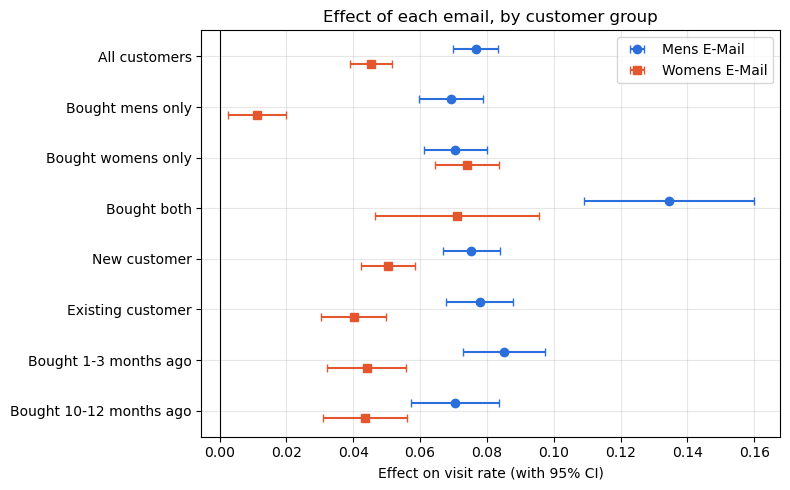

In [19]:
positions = np.arange(len(subgroup_effects))[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(subgroup_effects["mens_effect"], positions + 0.15,
            xerr=1.96 * subgroup_effects["mens_se"], fmt="o", color=BLUE, capsize=3, label="Mens E-Mail")
ax.errorbar(subgroup_effects["womens_effect"], positions - 0.15,
            xerr=1.96 * subgroup_effects["womens_se"], fmt="s", color=ORANGE, capsize=3, label="Womens E-Mail")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(positions)
ax.set_yticklabels(subgroup_effects["group"])
ax.set_xlabel("Effect on visit rate (with 95% CI)")
ax.set_title("Effect of each email, by customer group")
ax.legend()
plt.tight_layout()
plt.show()

**The two emails behave very differently.**

- The **men's email** raises visits by about 7 points in almost every group. It works on nearly everyone, so there is little to gain from being choosy.
- The **women's email** works for customers who buy women's products (about 7 points), but for customers who have **only bought men's products** the effect is close to zero (about 1 point). For this email, those customers are mostly **lost causes**.

So the women's email is the one where choosing *who* to email matters. **From here on we focus on the Womens E-Mail vs. No E-Mail comparison.** We do this, because the Mens E-Mail always works, so there is not much point in modeling it. In other words, if the business problem is maximizing the profits, then our work is pretty much done here, as we know the Mens E-Mail always works and we should do that. But to have something to do for our notebook, we use Womens E-Mail for our modeling.

In [20]:
womens_test = df[(df["segment"] == "Womens E-Mail") | (df["segment"] == "No E-Mail")].copy()
womens_test["treat"] = np.where(womens_test["segment"] == "Womens E-Mail", 1, 0)
print("Customers in the comparison:", len(womens_test))

Customers in the comparison: 42693


## 7. Predicting each customer's effect (uplift modeling)

Splitting by hand works for one or two columns, but customers differ in many ways at once. **Uplift models** use machine learning to estimate, for each customer:

> **uplift = (chance of visiting if emailed) − (chance of visiting if not emailed)**

A high uplift means "customers like this one are mostly persuadables."

We can't train a model on uplift directly, because we never see both outcomes for the same person. Instead, we use two tricks built from ordinary prediction models, plus one model built specifically for this job.

### Prepare the data

- **Features (X):** the "before" columns, with text columns turned into 0/1 columns.
- **Outcome (y):** `visit`.
- **Treatment (t):** 1 if emailed, 0 if not.

We train on 70% of customers and keep 30% aside as a **test set** to check the models honestly.

In [21]:
X = pd.get_dummies(womens_test[before_columns], dtype=float)
y = womens_test["visit"]
t = womens_test["treat"]

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t, test_size=0.3, random_state=42, stratify=t)

print("Training customers:", len(X_train))
print("Test customers:    ", len(X_test))

Training customers: 29885
Test customers:     12808


All models use the same kind of machine-learning model: **gradient boosting**, a collection of small decision trees. We keep the trees shallow and require at least 200 customers per leaf. Uplift differences are small, so the main danger is a model that memorizes noise.We use **HistGradientBoostingClassifier** because it runs faster than regular **GradientBoostingClassifier**. It bins the continuous values before deciding which split it should go to, which fastens things up.

In [22]:
def make_model():
    return HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=150,
                                          min_samples_leaf=200, random_state=42)

### Model 1: S-learner (one model)

1. Train **one** model to predict visits, using the features **plus** the treatment column.
2. For each test customer, ask the model twice: "What if this customer **was** emailed?" (treat = 1) and "What if they **weren't**?" (treat = 0).
3. Uplift = first answer − second answer.

In [23]:
X_train_with_treat = X_train.copy()
X_train_with_treat["treat"] = t_train

s_model = make_model()
s_model.fit(X_train_with_treat, y_train)
print("S-learner trained")

S-learner trained


In [24]:
X_test_if_emailed = X_test.copy()
X_test_if_emailed["treat"] = 1

X_test_if_not_emailed = X_test.copy()
X_test_if_not_emailed["treat"] = 0

chance_if_emailed = s_model.predict_proba(X_test_if_emailed)[:, 1]
chance_if_not_emailed = s_model.predict_proba(X_test_if_not_emailed)[:, 1]
uplift_s = chance_if_emailed - chance_if_not_emailed

### Model 2: T-learner (two models)

1. Train one model **only on emailed customers**, and another **only on non-emailed customers**.
2. For each test customer, get a prediction from each model.
3. Uplift = emailed-model prediction − non-emailed-model prediction.

The S-learner can end up nearly ignoring the treatment column if other features predict visits better. The T-learner can't ignore it, but each model only sees half of the data.

In [25]:
emailed = t_train == 1
not_emailed = t_train == 0

model_emailed = make_model()
model_emailed.fit(X_train[emailed], y_train[emailed])

model_not_emailed = make_model()
model_not_emailed.fit(X_train[not_emailed], y_train[not_emailed])

uplift_t = model_emailed.predict_proba(X_test)[:, 1] - model_not_emailed.predict_proba(X_test)[:, 1]

### Model 3: Causal forest

A **causal forest** (Athey & Wager) is a random forest designed for this problem. A normal decision tree splits customers into groups that differ in *how often they visit*. A causal tree splits them into groups that differ in *how much the email changes their visits*. The forest averages many such trees.

For example, say a tree is looking at the womens column (did they buy women's products before) as a candidate split, on the Womens-Email vs. No-Email data:

- Left group (womens = 1): among these customers, compare the emailed ones to the non-emailed ones → observed uplift ≈ 0.07
- Right group (womens = 0): compare emailed to non-emailed here too → observed uplift ≈ 0.01

Since 0.07 and 0.01 are very different, this split is a strong candidate — it separates customers by how much they respond

We use the `CausalForestDML` class from Microsoft's `econml` library. We give it:
- `model_y`: a model to predict visits from the features
- `model_t`: a model to predict who got emailed (in a randomized experiment this is just a coin flip, but the class requires it)

In [26]:
causal_forest = CausalForestDML(
    model_y=HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=150,
                                          min_samples_leaf=200, random_state=42),
    model_t=make_model(),
    discrete_treatment=True,
    n_estimators=500,
    min_samples_leaf=50,
    max_depth=8,
    random_state=42)

causal_forest.fit(y_train, t_train, X=X_train)
uplift_cf = causal_forest.effect(X_test)

### What do the predictions look like?

We put the three sets of predictions in one dictionary so we can loop over them.

In [27]:
uplift_scores = {"S-learner": uplift_s, "T-learner": uplift_t, "Causal forest": uplift_cf}

overall_effect = y_test[t_test == 1].mean() - y_test[t_test == 0].mean()
print("Average effect in the test set: %.4f" % overall_effect)

Average effect in the test set: 0.0359


The test-set average (about 3.6 points) is a bit lower than the 4.5 points we measured on all customers. That's just chance: which customers happened to land in the test set.

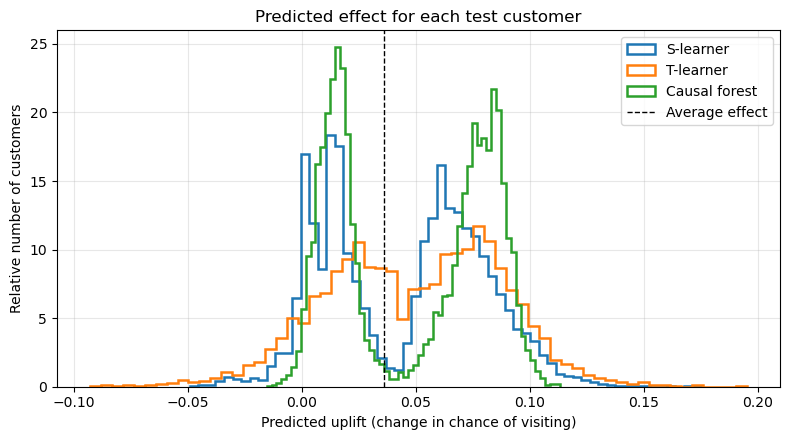

In [28]:
fig, ax = plt.subplots()
for name in uplift_scores:
    ax.hist(uplift_scores[name], bins=60, histtype="step", linewidth=1.8, density=True, label=name)
ax.axvline(overall_effect, color="black", linestyle="--", linewidth=1, label="Average effect")
ax.set_xlabel("Predicted uplift (change in chance of visiting)")
ax.set_ylabel("Relative number of customers")
ax.set_title("Predicted effect for each test customer")
ax.legend()
plt.tight_layout()
plt.show()

The models agree on the shape: **two humps**. One group of customers has a predicted uplift near 1–2 points (little to gain by emailing them). The other is near 7 points. That matches what we found by hand in Section 6. If we go to the graph in section 6, we see that the  Womens E-Mail effect on those who purchased only male products is about 1-2 points, and for the rest of the population that purchased women's products it is about 7 points. The current graph also supports that finding.

The T-learner's predictions spread widest, including some negative and some very large values: with two separate models, the errors of each add up.

## 8. Checking the models

We can't check any single customer's prediction, because we never see their true uplift. But we **can** check groups of customers:

1. Sort test customers from highest to lowest predicted uplift.
2. Cut them into 10 deciles: decile 1 has the highest predictions, decile 10 the lowest.
3. Inside each decile, compare emailed and non-emailed customers. Because the email was random, this is a small A/B test that shows the **real** effect for that decile.

If a model is good, the real effect should be large in the top deciles and small in the bottom ones.

In [29]:
def uplift_by_decile(uplift_score, y, t):
    table = pd.DataFrame({"score": uplift_score, "visit": y.values, "treat": t.values})
    table = table.sort_values("score", ascending=False).reset_index(drop=True)
    table["decile"] = table.index * 10 // len(table) + 1

    rows = []
    for decile in range(1, 11):
        part = table[table["decile"] == decile]
        emailed_rate = part.loc[part["treat"] == 1, "visit"].mean()
        not_emailed_rate = part.loc[part["treat"] == 0, "visit"].mean()
        rows.append({"decile": decile, "real_effect": emailed_rate - not_emailed_rate})
    return pd.DataFrame(rows)

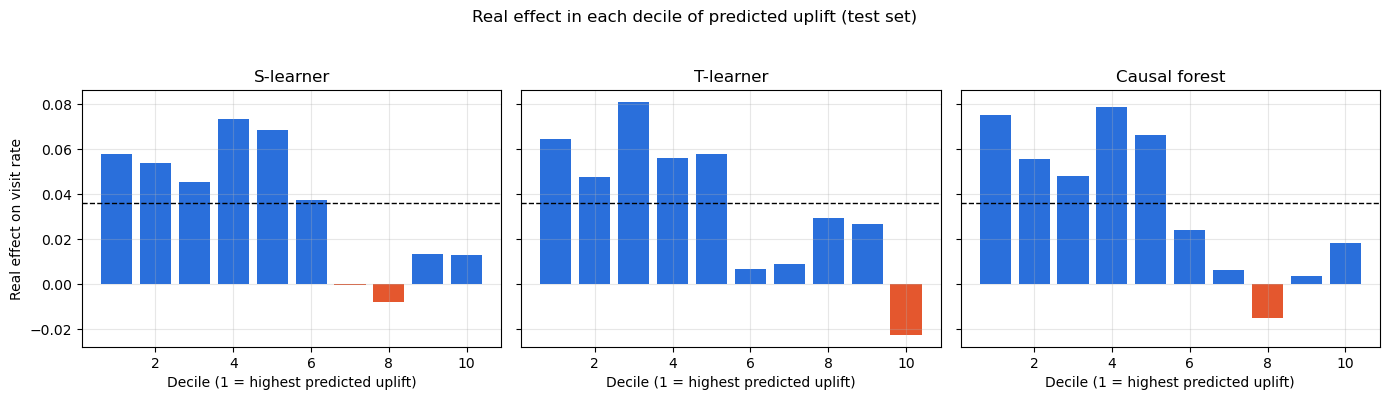

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
model_names = list(uplift_scores.keys())

for i in range(3):
    name = model_names[i]
    result = uplift_by_decile(uplift_scores[name], y_test, t_test)
    colors = np.where(result["real_effect"] > 0, BLUE, ORANGE)
    axes[i].bar(result["decile"], result["real_effect"], color=colors)
    axes[i].axhline(overall_effect, color="black", linestyle="--", linewidth=1)
    axes[i].set_title(name)
    axes[i].set_xlabel("Decile (1 = highest predicted uplift)")

axes[0].set_ylabel("Real effect on visit rate")
plt.suptitle("Real effect in each decile of predicted uplift (test set)", y=1.04)
plt.tight_layout()
plt.show()

All three models sort customers well. The top five deciles mostly show real effects above the average (dashed line), while the bottom five are close to zero. The small orange (negative) bars could be **sleeping dogs**, but with only about 1,300 customers per decile, bars this small are probably just noise. The bottom half is mostly **lost causes**.

### How many extra visits does targeting get us?

Now let's ask a business question: if we email only the top 10%, 20%, 30%… of customers (by predicted uplift), how many **extra visits** does the email produce?

For the top share of customers: *extra visits = (emailed visit rate − non-emailed visit rate) × number of customers*.

In [31]:
def extra_visits_curve(uplift_score, y, t):
    table = pd.DataFrame({"score": uplift_score, "visit": y.values, "treat": t.values})
    table = table.sort_values("score", ascending=False).reset_index(drop=True)

    rows = [{"share": 0.0, "customers": 0, "extra_visits": 0.0}]
    for step in range(1, 11):
        share = step / 10
        n_customers = int(share * len(table))
        top = table.iloc[:n_customers]
        emailed_rate = top.loc[top["treat"] == 1, "visit"].mean()
        not_emailed_rate = top.loc[top["treat"] == 0, "visit"].mean()
        extra = (emailed_rate - not_emailed_rate) * n_customers
        rows.append({"share": share, "customers": n_customers, "extra_visits": extra})
    return pd.DataFrame(rows)

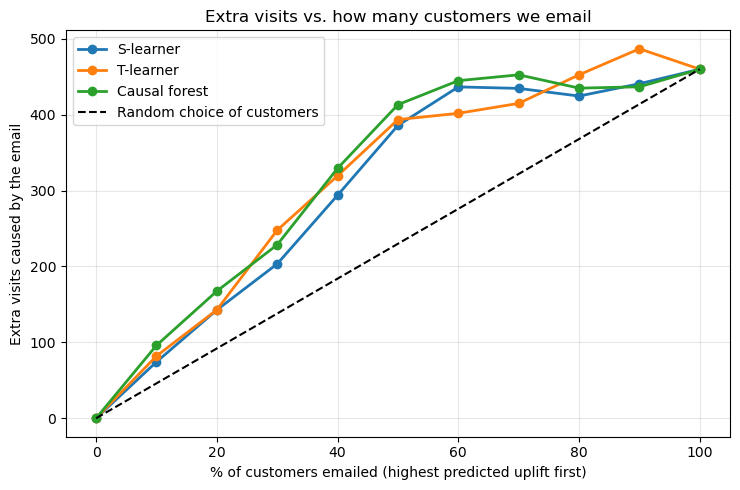

In [32]:
fig, ax = plt.subplots(figsize=(7.5, 5))

for name in uplift_scores:
    curve = extra_visits_curve(uplift_scores[name], y_test, t_test)
    ax.plot(100 * curve["share"], curve["extra_visits"], marker="o", linewidth=2, label=name)

everyone = curve["extra_visits"].iloc[-1]
ax.plot([0, 100], [0, everyone], color="black", linestyle="--", label="Random choice of customers")
ax.set_xlabel("% of customers emailed (highest predicted uplift first)")
ax.set_ylabel("Extra visits caused by the email")
ax.set_title("Extra visits vs. how many customers we email")
ax.legend()
plt.tight_layout()
plt.show()

The dashed line is what we'd get by emailing customers **at random**: each extra 10% of emails brings the same number of extra visits.

The model curves rise much faster at first — the first emails go to the persuadables — and then flatten, because the remaining customers are mostly lost causes. Emailing about half the customers gets most of the extra visits.

This kind of chart is called a **Qini curve**. The area between a model's curve and the dashed line is the **Qini score**: a single number for how well a model ranks customers. Higher is better; 0 means no better than random.

In [33]:
for name in uplift_scores:
    score = qini_auc_score(y_test, uplift_scores[name], t_test)
    print("%-14s Qini score: %.4f" % (name, score))

S-learner      Qini score: 0.0512
T-learner      Qini score: 0.0566
Causal forest  Qini score: 0.0588


The scores are close to each other. With a test set of about 12,800 customers, differences this small could be noise, so we shouldn't declare a clear winner. We'll use the **causal forest** from here on, because it also lets us look inside the model.

## 9. What drives the effect?

A marketing team won't trust "email these people" without a reason. The causal forest can tell us which features the email's effect depends on most.

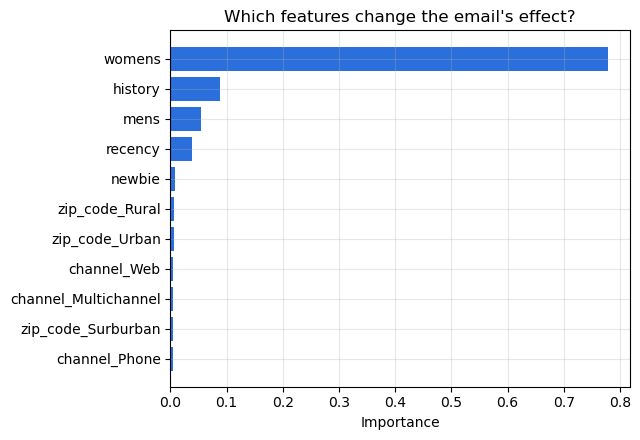

In [34]:
importance = pd.Series(causal_forest.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.barh(importance.index, importance.values, color=BLUE)
ax.set_title("Which features change the email's effect?")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

Note the difference from normal feature importance: this shows which features change **how much the email helps**, not which features predict visiting.

The top feature is `womens`. Let's check the forest against the data: for each purchase-history type, compare the forest's average prediction with a real A/B comparison in the test set.

In [35]:
test_history_type = womens_test.loc[X_test.index, "history_type"].values

rows = []
for group in ["Bought womens only", "Bought both", "Bought mens only"]:
    in_group = test_history_type == group
    group_visits = y_test[in_group]
    group_treat = t_test[in_group]
    real_effect = group_visits[group_treat == 1].mean() - group_visits[group_treat == 0].mean()

    row = {"group": group,
           "predicted_by_forest": uplift_cf[in_group].mean(),
           "real_effect_in_test_set": real_effect,
           "customers": in_group.sum()}
    rows.append(row)

check = pd.DataFrame(rows)
check.round(4)

,group,predicted_by_forest,real_effect_in_test_set,customers
0,Bought womens only,0.0775,0.0644,5766
1,Bought both,0.0794,0.0462,1246
2,Bought mens only,0.0141,0.0048,5796


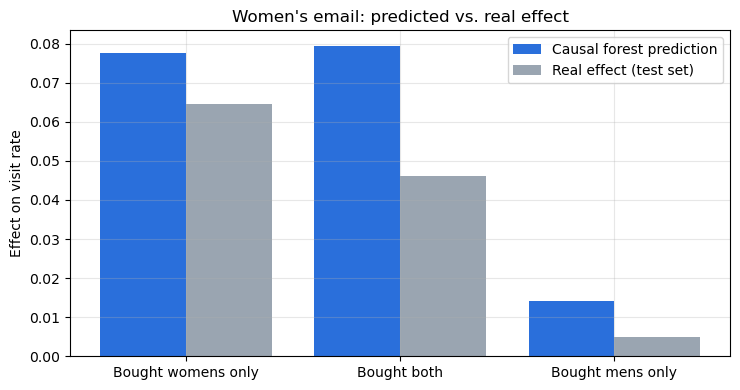

In [36]:
positions = np.arange(len(check))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(positions - 0.2, check["predicted_by_forest"], 0.4, color=BLUE, label="Causal forest prediction")
ax.bar(positions + 0.2, check["real_effect_in_test_set"], 0.4, color=GREY, label="Real effect (test set)")
ax.set_xticks(positions)
ax.set_xticklabels(check["group"])
ax.set_ylabel("Effect on visit rate")
ax.set_title("Women's email: predicted vs. real effect")
ax.legend()
plt.tight_layout()
plt.show()

The forest gets the pattern right: a large effect for women's buyers and almost none for men's-only buyers. (For "Bought both" the forest predicts more than the test set shows, but that group has only about 1,250 test customers, so its real effect is measured with a lot of noise.) The story is easy to explain: **the women's email works on people who already buy women's products, and does almost nothing for people who have only bought men's products.** Recency, channel and zip code barely matter.

The forest found this on its own, from 11 features.

## 10. The business decision: how many customers should we email?

To turn extra visits into money, we need two numbers. **Change them to match your own business.**

- **Cost per email (`COST`).** Sending an email is almost free, but every email also risks annoying customers and causing unsubscribes. We use \$0.10 per email. For printed direct mail, this would be the real printing and postage cost.
- **Profit per extra visit (`VALUE_PER_VISIT`).** We estimate this as *(average spend per visit) × (profit margin)*, assuming a 35% margin.

Then for each share of customers emailed:

> **profit = extra visits × value per visit − number of emails × cost per email**

In [37]:
COST = 0.10
MARGIN = 0.35

spend_per_visit = df["spend"].sum() / df["visit"].sum()
VALUE_PER_VISIT = MARGIN * spend_per_visit

print("Average spend per visit:  $%.2f" % spend_per_visit)
print("Profit per extra visit:   $%.2f" % VALUE_PER_VISIT)

Average spend per visit:  $7.16
Profit per extra visit:   $2.51


In [38]:
curve = extra_visits_curve(uplift_cf, y_test, t_test)
curve["profit"] = curve["extra_visits"] * VALUE_PER_VISIT - curve["customers"] * COST
curve.round(2)

,share,customers,extra_visits,profit
0,0.0,0,0.00,0.00
1,0.1,1280,96.00,112.57
2,0.2,2561,167.47,163.57
3,0.3,3842,228.57,188.56
4,0.4,5123,329.31,312.92
5,0.5,6404,413.16,394.93
6,0.6,7684,444.79,346.20
7,0.7,8965,452.46,237.31
8,0.8,10246,434.96,65.36
9,0.9,11527,436.68,-58.43


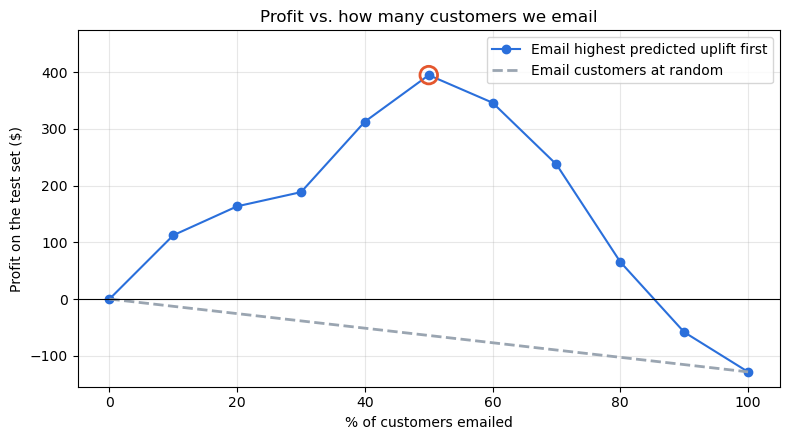

In [39]:
best_row = curve.loc[curve["profit"].idxmax()]
profit_everyone = curve["profit"].iloc[-1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(100 * curve["share"], curve["profit"], marker="o", color=BLUE, label="Email highest predicted uplift first")
ax.plot([0, 100], [0, profit_everyone], color=GREY, linestyle="--", linewidth=2, label="Email customers at random")
ax.scatter(100 * best_row["share"], best_row["profit"], s=160, facecolor="none", edgecolor=ORANGE, linewidth=2, zorder=5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylim(top=best_row["profit"] * 1.2)
ax.set_xlabel("% of customers emailed")
ax.set_ylabel("Profit on the test set ($)")
ax.set_title("Profit vs. how many customers we email")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [40]:
print("Email everyone:     %5d emails -> profit $%.0f" % (curve["customers"].iloc[-1], profit_everyone))
print("Email the top %d%%:  %5d emails -> profit $%.0f" % (100 * best_row["share"], best_row["customers"], best_row["profit"]))

Email everyone:     12808 emails -> profit $-128
Email the top 50%:   6404 emails -> profit $395


**Reading the chart.** Emailing at random gives a straight line: every email earns the same average profit — and at \$0.10 per email, that average is slightly *negative*, so emailing everyone loses money. Emailing in order of predicted uplift gives a hill. The first emails go to persuadables and earn a lot; later emails go to lost causes (mostly men's-only buyers) and cost more than they bring in. The top of the hill is the best number of customers to email.

**The best cutoff depends on the cost.** Let's try a few different costs per email:

In [41]:
for cost in [0.02, 0.05, 0.10, 0.15]:
    profit = curve["extra_visits"] * VALUE_PER_VISIT - curve["customers"] * cost
    best_share = curve["share"][profit.idxmax()]
    print("Cost $%.2f per email -> best share to email: %d%%, profit $%.0f (email everyone: $%.0f)"
          % (cost, 100 * best_share, profit.max(), profit.iloc[-1]))

Cost $0.02 per email -> best share to email: 60%, profit $961 (email everyone: $896)
Cost $0.05 per email -> best share to email: 60%, profit $730 (email everyone: $512)
Cost $0.10 per email -> best share to email: 50%, profit $395 (email everyone: $-128)
Cost $0.15 per email -> best share to email: 50%, profit $75 (email everyone: $-769)


When emails are cheap, a wide audience pays off and targeting adds only a little. As the cost rises, targeting matters more and more: at \$0.10 or more per email, emailing everyone loses money while emailing the top half still earns a profit.

**A caution:** these profit numbers come from a test set of about 12,800 customers, so they are estimates with real uncertainty. The ranking of customers is the model's main output; the exact cutoff is a business choice.

## 11. Summary

| Question | Answer |
|---|---|
| Was the experiment set up correctly? | Yes. The groups are equal in size, and they looked alike before the email (every SMD below 0.02). |
| Did the emails work? | Yes. The men's email raised visits by 7.7 points (+72%) and spend by 0.77 dollars per customer; the women's email by 4.5 points and 0.42 dollars. |
| Could CUPED make the estimate more precise? | Only a little here, because last year's spend barely predicts spend in a two-week window. |
| Who did the emails work for? | The men's email worked on nearly everyone. The women's email worked on women's-product buyers and barely at all on men's-only buyers. |
| Does targeting pay off? | Yes, for the women's email. Emailing the top half of customers by predicted uplift gets about 90% of the extra visits with half the emails. At \$0.10 per email, that turns a loss (emailing everyone) into a profit. |

### What this project shows

- **Checking an experiment:** group sizes and balance before trusting any result
- **Measuring an effect:** difference in averages, confidence intervals, and the regression version
- **Precision:** CUPED, and when it does and doesn't help
- **Effects for different customers:** subgroup analysis, S-learner, T-learner, causal forest
- **Checking models without knowing the truth:** decile charts and Qini curves on a test set
- **A business decision:** a profit curve with clear, adjustable assumptions

### Ideas for next steps

- **Pick the best email for each customer.** The results suggest sending men's-only buyers the men's email instead of the women's.
- **Compare with a simple rule.** Since one feature drives most of the effect, compare the model against "don't send the women's email to men's-only buyers."
- **Test it for real.** Keep a random no-email group in the next campaign to confirm the targeting works.

### References

- Hillstrom, K. (2008). *The MineThatData E-Mail Analytics and Data Mining Challenge.*
- Deng, A., Xu, Y., Kohavi, R., & Walker, T. (2013). Improving the sensitivity of online controlled experiments by utilizing pre-experiment data (CUPED). *WSDM.*
- Wager, S., & Athey, S. (2018). Estimation and inference of heterogeneous treatment effects using random forests. *JASA.*
- Künzel, S., Sekhon, J., Bickel, P., & Yu, B. (2019). Metalearners for estimating heterogeneous treatment effects using machine learning. *PNAS.*